In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

Задание №1.
1.Выберите и оставьте числовые признаки, по которым будете определять тип животных, и целевую переменную - Рор
2.Закодируйте значения по столбцу Рор в 0 и 1 (можно использовать метод LabelEncoder)
3.Разделите данные на выборку для обучения и тестирования (в соотношении 80 - тренировочная, 20 - тестовая)
4.Постройте модель LDA
5.Рассчитайте точность вашей модели на тестовой выборке

In [25]:
dfs = pd.read_csv('possum.csv')
dfs[['case', 'site']] = dfs[['case', 'site']].astype('category')
df = dfs.select_dtypes(include=['number'])
df['Pop'] = dfs['Pop']
df = df.drop(columns=['age'])
df.dropna(inplace=True)
le = LabelEncoder()
df['Pop'] = le.fit_transform(df['Pop'])
df.head()

,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,Pop
0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0,0
1,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0,0
2,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0,0
3,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0,0
4,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0,0


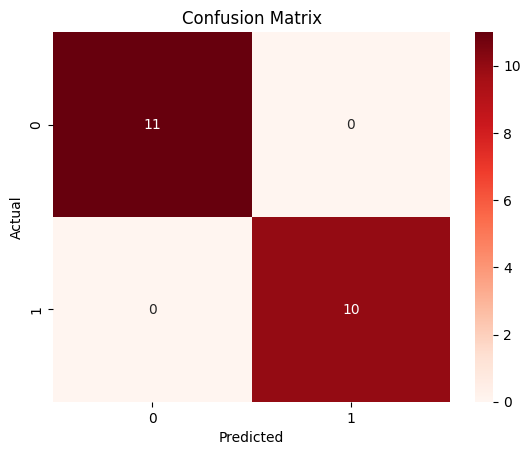

In [29]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Pop']), df['Pop'], test_size=0.2, random_state=42)
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()  

Задание №2
1.Выберите и оставьте только те признаки, по которым будете проводить кластерный анализ.
2.Подберите оптимальное число кластеров для алгоритма K-means.
3.Визуализируйте полученную кластеризацию.
4.Проверьте правильность выбора кластеров с помощью метода локтя.
5.Примените алгомеративную кластеризацию с учётом рассчитанного методом локтя оптимального количества кластеров.
6.Визуализируйте результат.

In [59]:
dfs = pd.read_csv('Country-data.csv')

features = [
    'child_mort',
    'exports',
    'health',
    'imports',
    'income',
    'inflation',
    'life_expec',
    'total_fer',
    'gdpp'
]

df = dfs[features]
df.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [60]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [61]:
inertia = []
K_Range = range(1, 11)

for k in K_Range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

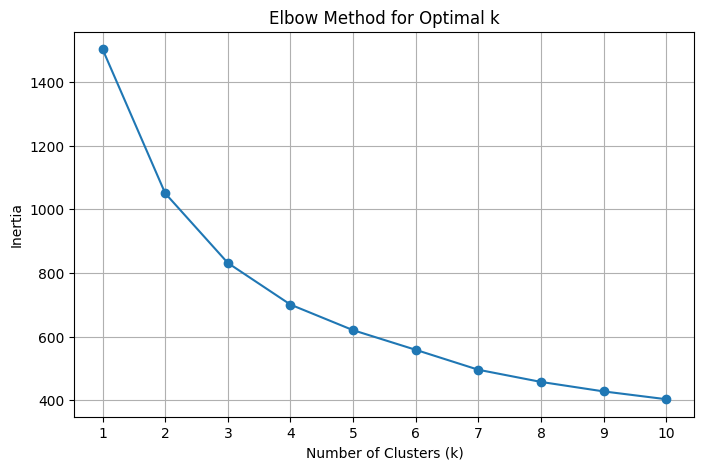

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(K_Range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(K_Range)
plt.grid(True)
plt.show()

In [64]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_scaled['Cluster'] = kmeans.fit_predict(df_scaled)
df_scaled["Cluster"].value_counts()

Cluster
2    85
1    47
0    32
3     3
Name: count, dtype: int64

In [75]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled.drop(columns=['Cluster']))
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_scaled['Cluster']
df_pca['country'] = dfs['country']
df_pca.head()

,PC1,PC2,Cluster,country
0,-2.913025,0.095621,1,Afghanistan
1,0.429911,-0.588156,2,Albania
2,-0.285225,-0.455174,2,Algeria
3,-2.932423,1.695555,1,Angola
4,1.033576,0.136659,2,Antigua and Barbuda


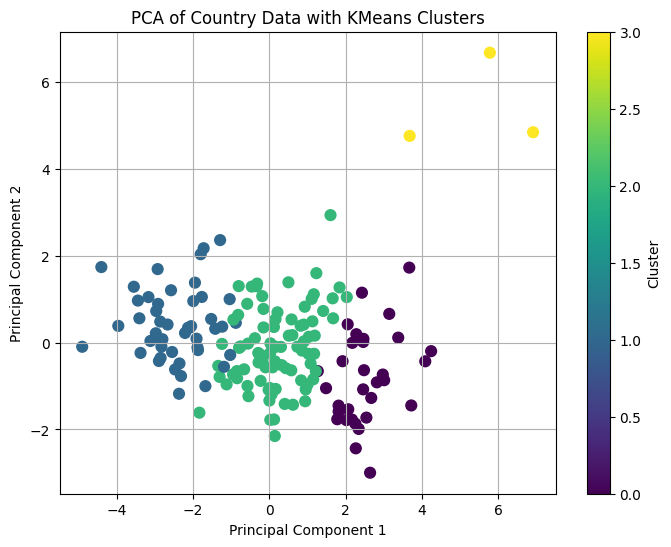

In [66]:
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', s=60)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Country Data with KMeans Clusters')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [86]:
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
df_pca['agglo_cluster'] = agglo.fit_predict(df_scaled)
df_pca['agglo_cluster'].value_counts()

agglo_cluster
2    87
0    45
1    32
3     3
Name: count, dtype: int64

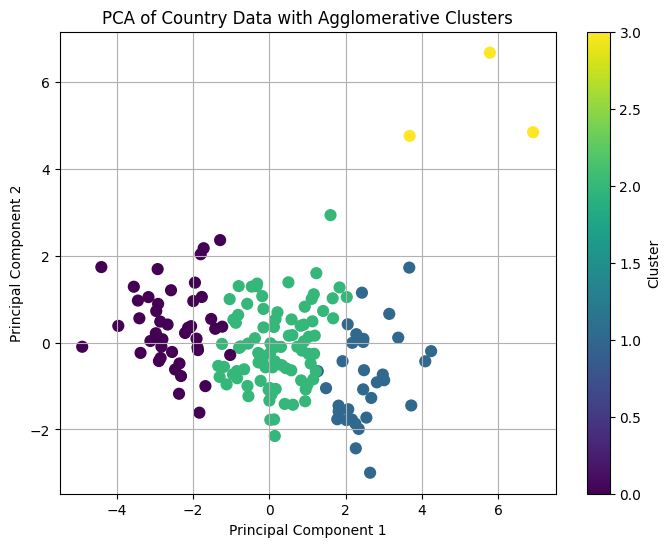

In [68]:
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['agglo_cluster'], cmap='viridis', s=60)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Country Data with Agglomerative Clusters')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [88]:
df_pca[['country', 'Cluster', 'agglo_cluster']].head(20)

,country,Cluster,agglo_cluster
0,Afghanistan,1,0
1,Albania,2,2
2,Algeria,2,2
3,Angola,1,0
4,Antigua and Barbuda,2,2
5,Argentina,2,2
6,Armenia,2,2
7,Australia,0,1
8,Austria,0,1
9,Azerbaijan,2,2


In [89]:
df['kmeans_cluster'] = df_pca['Cluster']
df.groupby('kmeans_cluster')[features].mean().T

kmeans_cluster,0,1,2,3
child_mort,5.181250,92.961702,21.690588,4.133333
exports,46.118750,29.151277,41.073988,176.000000
health,9.088437,6.388511,6.197059,6.793333
imports,40.584375,42.323404,47.914893,156.666667
income,44021.875000,3942.404255,12671.411765,64033.333333
inflation,2.513844,12.019681,7.609341,2.468000
life_expec,80.081250,59.187234,72.871765,81.433333
total_fer,1.788437,5.008085,2.300706,1.380000
gdpp,42118.750000,1922.382979,6519.552941,57566.666667


In [91]:
df['agglo_cluster'] = df_pca['agglo_cluster']
df.groupby('agglo_cluster')[features].mean().T

agglo_cluster,0,1,2,3
child_mort,94.920000,5.181250,22.316092,4.133333
exports,27.782644,46.118750,41.507816,176.000000
health,6.182444,9.088437,6.308046,6.793333
imports,41.108131,40.584375,48.414943,156.666667
income,3450.066667,44021.875000,12725.402299,64033.333333
inflation,12.291889,2.513844,7.569931,2.468000
life_expec,59.524444,80.081250,72.382759,81.433333
total_fer,5.082667,1.788437,2.324368,1.380000
gdpp,1611.555556,42118.750000,6574.643678,57566.666667


В ходе работы был выполнен кластерный анализ стран на основе девяти числовых социально-экономических признаков. Текстовый признак country был исключён из анализа, так как он не является числовым показателем.

Перед применением алгоритмов данные были стандартизированы с помощью StandardScaler, что позволило привести все признаки к единому масштабу.

С помощью метода локтя было проанализировано изменение inertia при разном количестве кластеров. Для дальнейшего анализа было выбрано k = 4, так как такое количество кластеров позволяет получить более детальное разделение стран по уровню развития.

Метод K-means разделил страны на четыре группы. Для визуализации результата была применена PCA, которая уменьшила размерность данных с 9 признаков до 2 главных компонент. Это позволило отобразить страны на двумерной плоскости, где цвет каждой точки соответствует номеру кластера.

Затем была применена агломеративная кластеризация с тем же количеством кластеров. Её результат также был визуализирован на плоскости главных компонент.

Полученные четыре кластера можно содержательно интерпретировать как группы стран с различным уровнем социально-экономического развития: страны с низким уровнем развития, развивающиеся страны, страны со средним или высоким уровнем развития и наиболее развитые или богатые страны.

Таким образом, кластеризация позволила выделить группы стран, похожих между собой по демографическим, экономическим и социальным показателям.